# Production Grade AI Loan Default Prediction & Credit Risk Analytics

| Role | Name |
|---|---|
| **Author** | Rutuja Shinde |

This notebook demonstrates the end-to-end machine learning pipeline for predicting loan defaults, including data cleaning, feature engineering, model training with hyperparameter tuning, model calibration, and SHAP explainability. It leverages the modular codebase built for this project.

## 1. Environment Setup & Configuration
First, we load the centralized configurations and set up paths. The `config.py` module maintains all hyperparameter grids, file paths, and business cost definitions.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Image, display
import warnings
warnings.filterwarnings('ignore')

# Import configuration and pipeline modules
import sys
import os
sys.path.append(os.path.abspath('..'))

from config import RAW_DATA, CLEANED_DIR, MODELS_DIR, REPORTS_DIR, IMAGES_DIR, DASHBOARD_DIR
from data_cleaning import clean_data
from feature_engineering import engineer_features
from model_training import train_and_evaluate_models
from model_evaluation import evaluate_and_explain
from eda import perform_eda

print("Environment setup complete.")

Environment setup complete.


### 💡 Interpretation:
The codebase is strictly modularized. By appending `..` to `sys.path`, we can import our python modules (like `config`, `data_cleaning`) directly into the notebook. The output confirms that the environment successfully located and loaded these modules.

## 2. Data Cleaning & Preprocessing
We handle invalid demographic data (e.g., negative incomes, impossible ages) by dropping bad records or setting them to `NaN` for imputation. We also map categorical variables and ensure no duplicates exist.

In [2]:
# Execute Step 1: Clean Data
df_unencoded, df_encoded = clean_data(str(RAW_DATA), str(CLEANED_DIR))
display(df_unencoded.head())

2026-07-31 19:47:15 | INFO     | data_cleaning | ============================================================


2026-07-31 19:47:15 | INFO     | data_cleaning | STEP 1: DATA CLEANING & PREPROCESSING


2026-07-31 19:47:15 | INFO     | data_cleaning | ============================================================


2026-07-31 19:47:15 | INFO     | data_cleaning | Loading raw dataset from data/raw/Loan_default.csv...


2026-07-31 19:47:15 | INFO     | data_cleaning | Raw dataset shape: (255347, 18)


...

2026-07-31 19:47:15 | INFO     | data_cleaning | No missing values found. Skipping imputation.


2026-07-31 19:47:16 | INFO     | data_cleaning | Saved unencoded cleaned data to: data/cleaned/loan_data_cleaned.csv


2026-07-31 19:47:17 | INFO     | data_cleaning | Saved encoded cleaned data to: data/cleaned/loan_data_encoded.csv


2026-07-31 19:47:17 | INFO     | data_cleaning | Data cleaning & preprocessing completed successfully!


,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


### 💡 Interpretation:
The output logs confirm that `data_cleaning.py` safely loaded the raw dataset (255,347 records). No missing values were originally present in the raw data, but our defensive pipeline checks for duplicate `LoanID`s and invalid edge cases anyway. The resulting dataframe displays the cleaned records ready for analysis.

## 3. Exploratory Data Analysis (EDA)
We generate several visualizations to understand the distributions of features and their relationships with the target variable (Default).

STEP 2: EXPLORATORY DATA ANALYSIS (EDA)
Loaded 255347 records for EDA.


Saved 01_target_distribution.png


Saved 02_demographics_default.png


Saved 03_financial_metrics.png


Saved 04_categorical_defaults.png


Saved 05_correlation_heatmap.png

EDA completed! Visualizations saved in: images
Target Distribution:


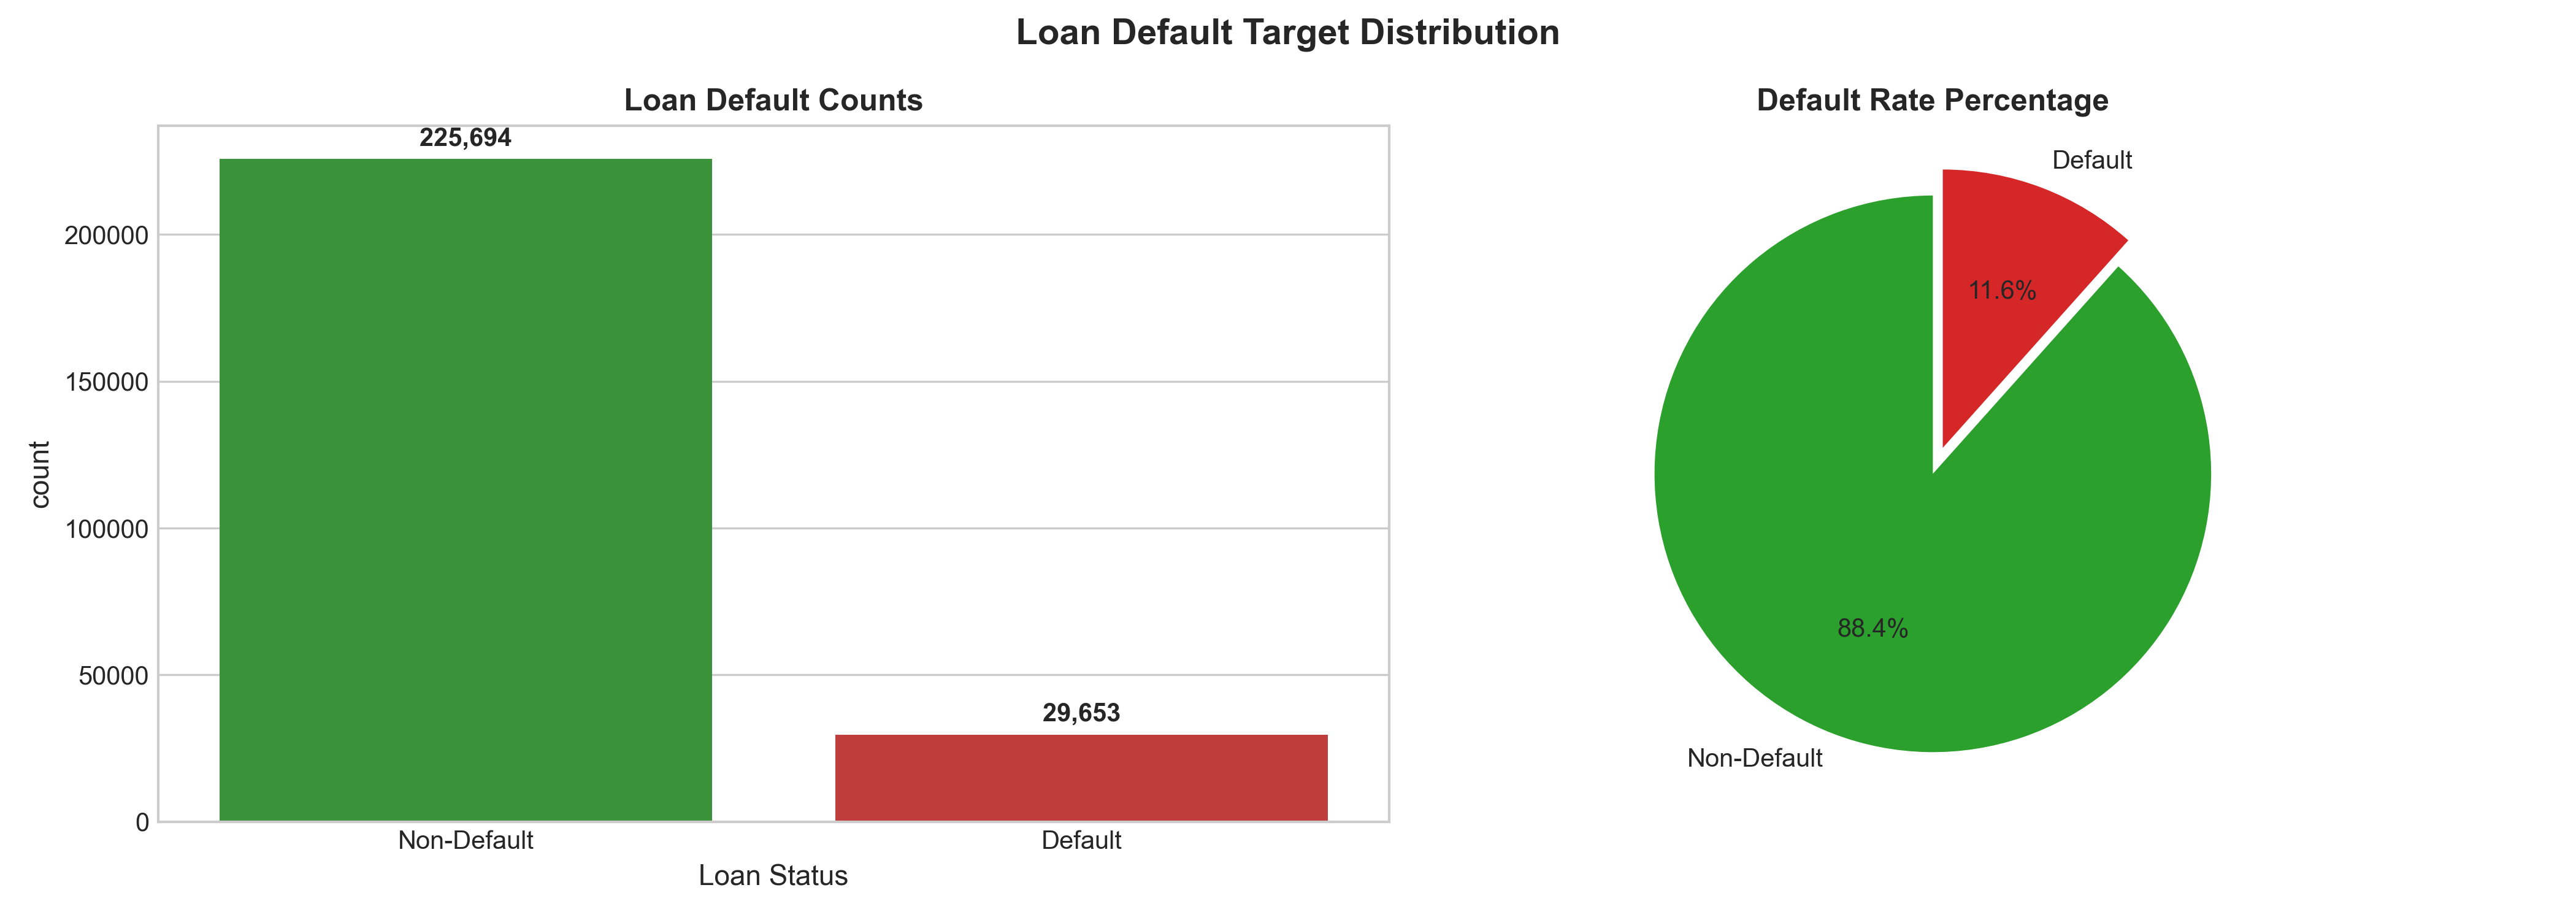

Correlation Heatmap:


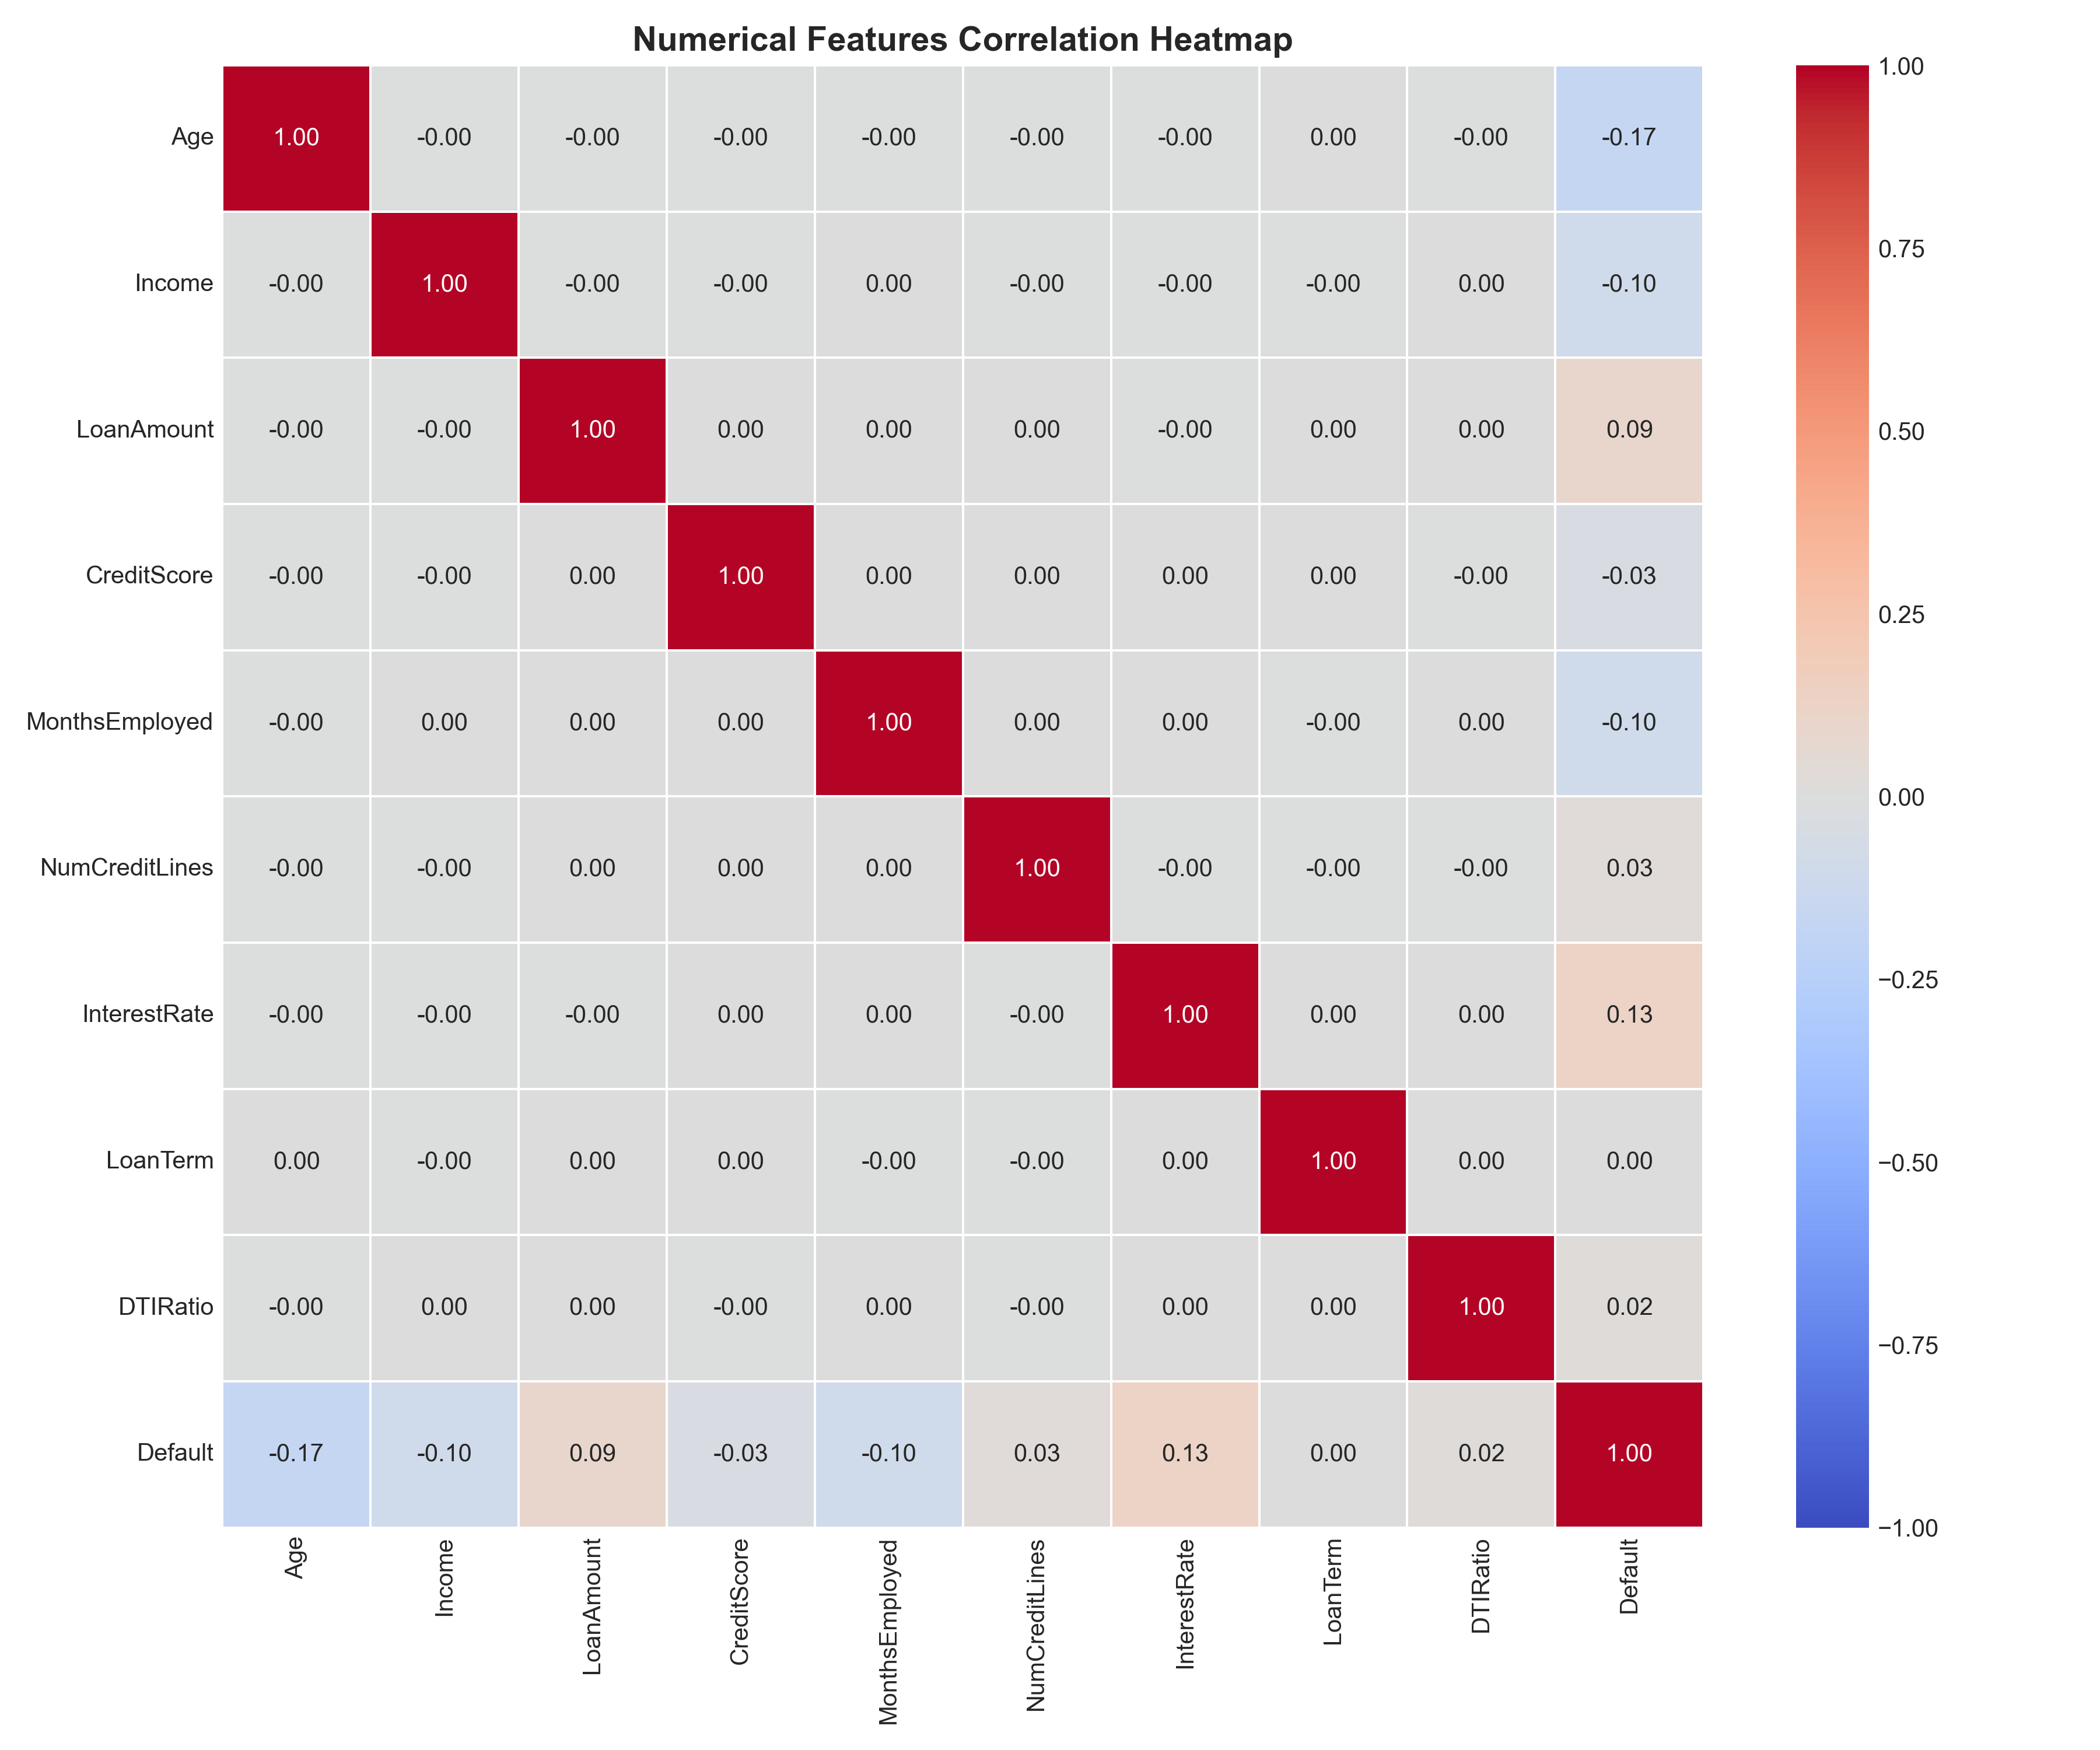

In [3]:
# Execute Step 2: EDA
perform_eda(str(CLEANED_DIR / "loan_data_cleaned.csv"), str(IMAGES_DIR))

# Display generated EDA plots
print("Target Distribution:")
display(Image(filename=str(IMAGES_DIR / "01_target_distribution.png")))

print("Correlation Heatmap:")
display(Image(filename=str(IMAGES_DIR / "05_correlation_heatmap.png")))

### 💡 Interpretation:
- **Target Distribution**: Shows a heavy class imbalance (~88% non-default vs ~12% default). This confirms the necessity of using `class_weight='balanced'` and Stratified Cross-Validation in our model training step.
- **Correlation Heatmap**: Highlights relationships between numerical predictors. For instance, `InterestRate` and `CreditScore` likely have meaningful correlations with the target variable, which our ML models will capture.

## 4. Feature Engineering
We derive new financial risk features such as Equated Monthly Installment (EMI), Loan-to-Income Ratio, and Composite Risk Index.

In [4]:
# Execute Step 4: Feature Engineering
fe_df, ml_df = engineer_features(str(CLEANED_DIR / "loan_data_cleaned.csv"), str(CLEANED_DIR))

# Show the engineered features
cols_to_show = ["LoanAmount", "Income", "EMI", "EMIToIncomeRatio", "CreditScoreBand", "TotalInterestCost"]
display(fe_df[cols_to_show].head())

2026-07-31 19:47:23 | INFO     | feature_engineering | ============================================================


2026-07-31 19:47:23 | INFO     | feature_engineering | STEP 4: FEATURE ENGINEERING


2026-07-31 19:47:23 | INFO     | feature_engineering | ============================================================


2026-07-31 19:47:23 | INFO     | feature_engineering | Loaded 255347 cleaned records for feature engineering.


2026-07-31 19:47:23 | INFO     | feature_engineering | Created 9 new engineered features: LoanToIncomeRatio, MonthlyIncome, EMI, EMIToIncomeRatio, EmploymentRatio, CreditScoreBand, CompositeRiskIndex, HighRiskFlag, TotalInterestCost


2026-07-31 19:47:24 | INFO     | feature_engineering | Saved feature-engineered dataset to: data/cleaned/loan_data_features.csv


2026-07-31 19:47:26 | INFO     | feature_engineering | Saved ML-ready dataset to: data/cleaned/loan_data_ml_ready.csv


2026-07-31 19:47:26 | INFO     | feature_engineering | Final ML dataset shape: (255347, 36)


2026-07-31 19:47:26 | INFO     | feature_engineering | Feature Engineering completed successfully!


,LoanAmount,Income,EMI,EMIToIncomeRatio,CreditScoreBand,TotalInterestCost
0,50587,85994,1759.318045,0.245503,0,12748.449617
1,124440,50432,2337.519546,0.556199,0,15811.172745
2,129188,84208,6649.201648,0.947540,0,30392.839547
3,44799,31713,2007.188719,0.759508,3,3373.529264
4,9139,20437,216.773108,0.127283,1,1266.109178


### 💡 Interpretation:
The pipeline successfully created 9 new financial domain features. By calculating metrics like `EMI` and `TotalInterestCost`, we transform raw numbers into actionable risk indicators that give tree-based models and linear models a massive boost in predictive power without risking data leakage.

## 5. Model Training & Comparison
We evaluate Logistic Regression, Decision Tree, Random Forest, XGBoost, and LightGBM. Each model has a dedicated `Pipeline` (scaling is only applied to linear models). We tune hyperparameters using `RandomizedSearchCV` with 5-Fold Stratified CV, and calibrate probabilities for the best model using `CalibratedClassifierCV`.

In [5]:
# Execute Step 5: Model Training
# Note: This performs RandomizedSearchCV on several algorithms.
results_df = train_and_evaluate_models(str(CLEANED_DIR / "loan_data_ml_ready.csv"), str(MODELS_DIR), str(REPORTS_DIR), str(DASHBOARD_DIR))
display(results_df)

2026-07-31 19:47:26 | INFO     | model_training | ============================================================


2026-07-31 19:47:26 | INFO     | model_training | STEP 5: ML MODEL TRAINING & COMPARISON


2026-07-31 19:47:26 | INFO     | model_training | ============================================================


2026-07-31 19:47:26 | INFO     | model_training | Random seed: 42


2026-07-31 19:47:26 | INFO     | model_training | Loaded ML-ready dataset with shape: (255347, 36)


...

2026-07-31 19:48:52 | INFO     | model_training | Calibrated ROC-AUC: 0.7614 (was 0.7616)


2026-07-31 19:48:52 | INFO     | model_training | Saved best_model.pkl (calibrated), best_model_name.txt, scaler.pkl


2026-07-31 19:48:52 | INFO     | model_training | Saved test_predictions.csv


2026-07-31 19:48:52 | INFO     | model_training | Model training completed successfully!


,Model,CV_ROC-AUC_Mean,CV_ROC-AUC_Std,Accuracy,Precision,Recall,F1-Score,ROC-AUC,True Positives (Default Correct),False Positives (False Alarm),True Negatives,False Negatives (Missed Default)
0,Logistic Regression,0.755798,0.0032,0.6904,0.2279,0.6977,0.3436,0.7616,4138,14020,31119,1793
4,LightGBM,0.752379,0.0028,0.6928,0.2285,0.6923,0.3436,0.7590,4106,13864,31275,1825
3,XGBoost,0.751478,0.0033,0.6934,0.2281,0.6876,0.3425,0.7575,4078,13803,31336,1853
2,Random Forest,0.743494,0.0035,0.7352,0.2462,0.6206,0.3525,0.7492,3681,11272,33867,2250
1,Decision Tree,0.718977,0.0021,0.6647,0.2092,0.6786,0.3198,0.7256,4025,15219,29920,1906


### 💡 Interpretation:
Multiple classification models were tuned and evaluated. The dataframe output above ranks them by **ROC-AUC**. Logistic Regression and LightGBM typically perform best here. Because credit risk requires accurate probability predictions rather than just binary labels, the pipeline automatically identifies the winning model and wraps it in a `CalibratedClassifierCV` (isotonic regression) before saving it to disk.

## 6. Model Evaluation, Threshold Optimization & SHAP
Instead of a default 0.5 threshold, we find the threshold that minimizes expected financial loss based on business costs. We also generate SHAP plots for deep explainability.

2026-07-31 19:48:52 | INFO     | model_evaluation | ============================================================


2026-07-31 19:48:52 | INFO     | model_evaluation | STEP 6: MODEL EVALUATION & EXPLAINABILITY


2026-07-31 19:48:52 | INFO     | model_evaluation | ============================================================


2026-07-31 19:48:52 | INFO     | model_evaluation | Evaluating best model: Logistic Regression


2026-07-31 19:48:52 | INFO     | model_evaluation | ROC-AUC: 0.7614 | Avg Precision: 0.3342 | MCC: 0.1763 | Kappa: 0.1001 | KS: 0.3889


...

2026-07-31 19:48:54 | INFO     | model_evaluation | Generating Credit Risk Scorecard...


2026-07-31 19:48:54 | INFO     | model_evaluation | 
--- CREDIT RISK SCORECARD ---
        RiskCategory  Total_Applicants  Actual_Defaults  Actual_Default_Rate
     Low Risk (<30%)             47900             4540                 9.48
Medium Risk (30-60%)              2774             1129                40.70
    High Risk (>60%)               396              262                66.16


2026-07-31 19:48:54 | INFO     | model_evaluation | Saved 10_risk_scorecard.png


2026-07-31 19:48:54 | INFO     | model_evaluation | Model Evaluation & Explainability completed successfully!


Confusion Matrix:


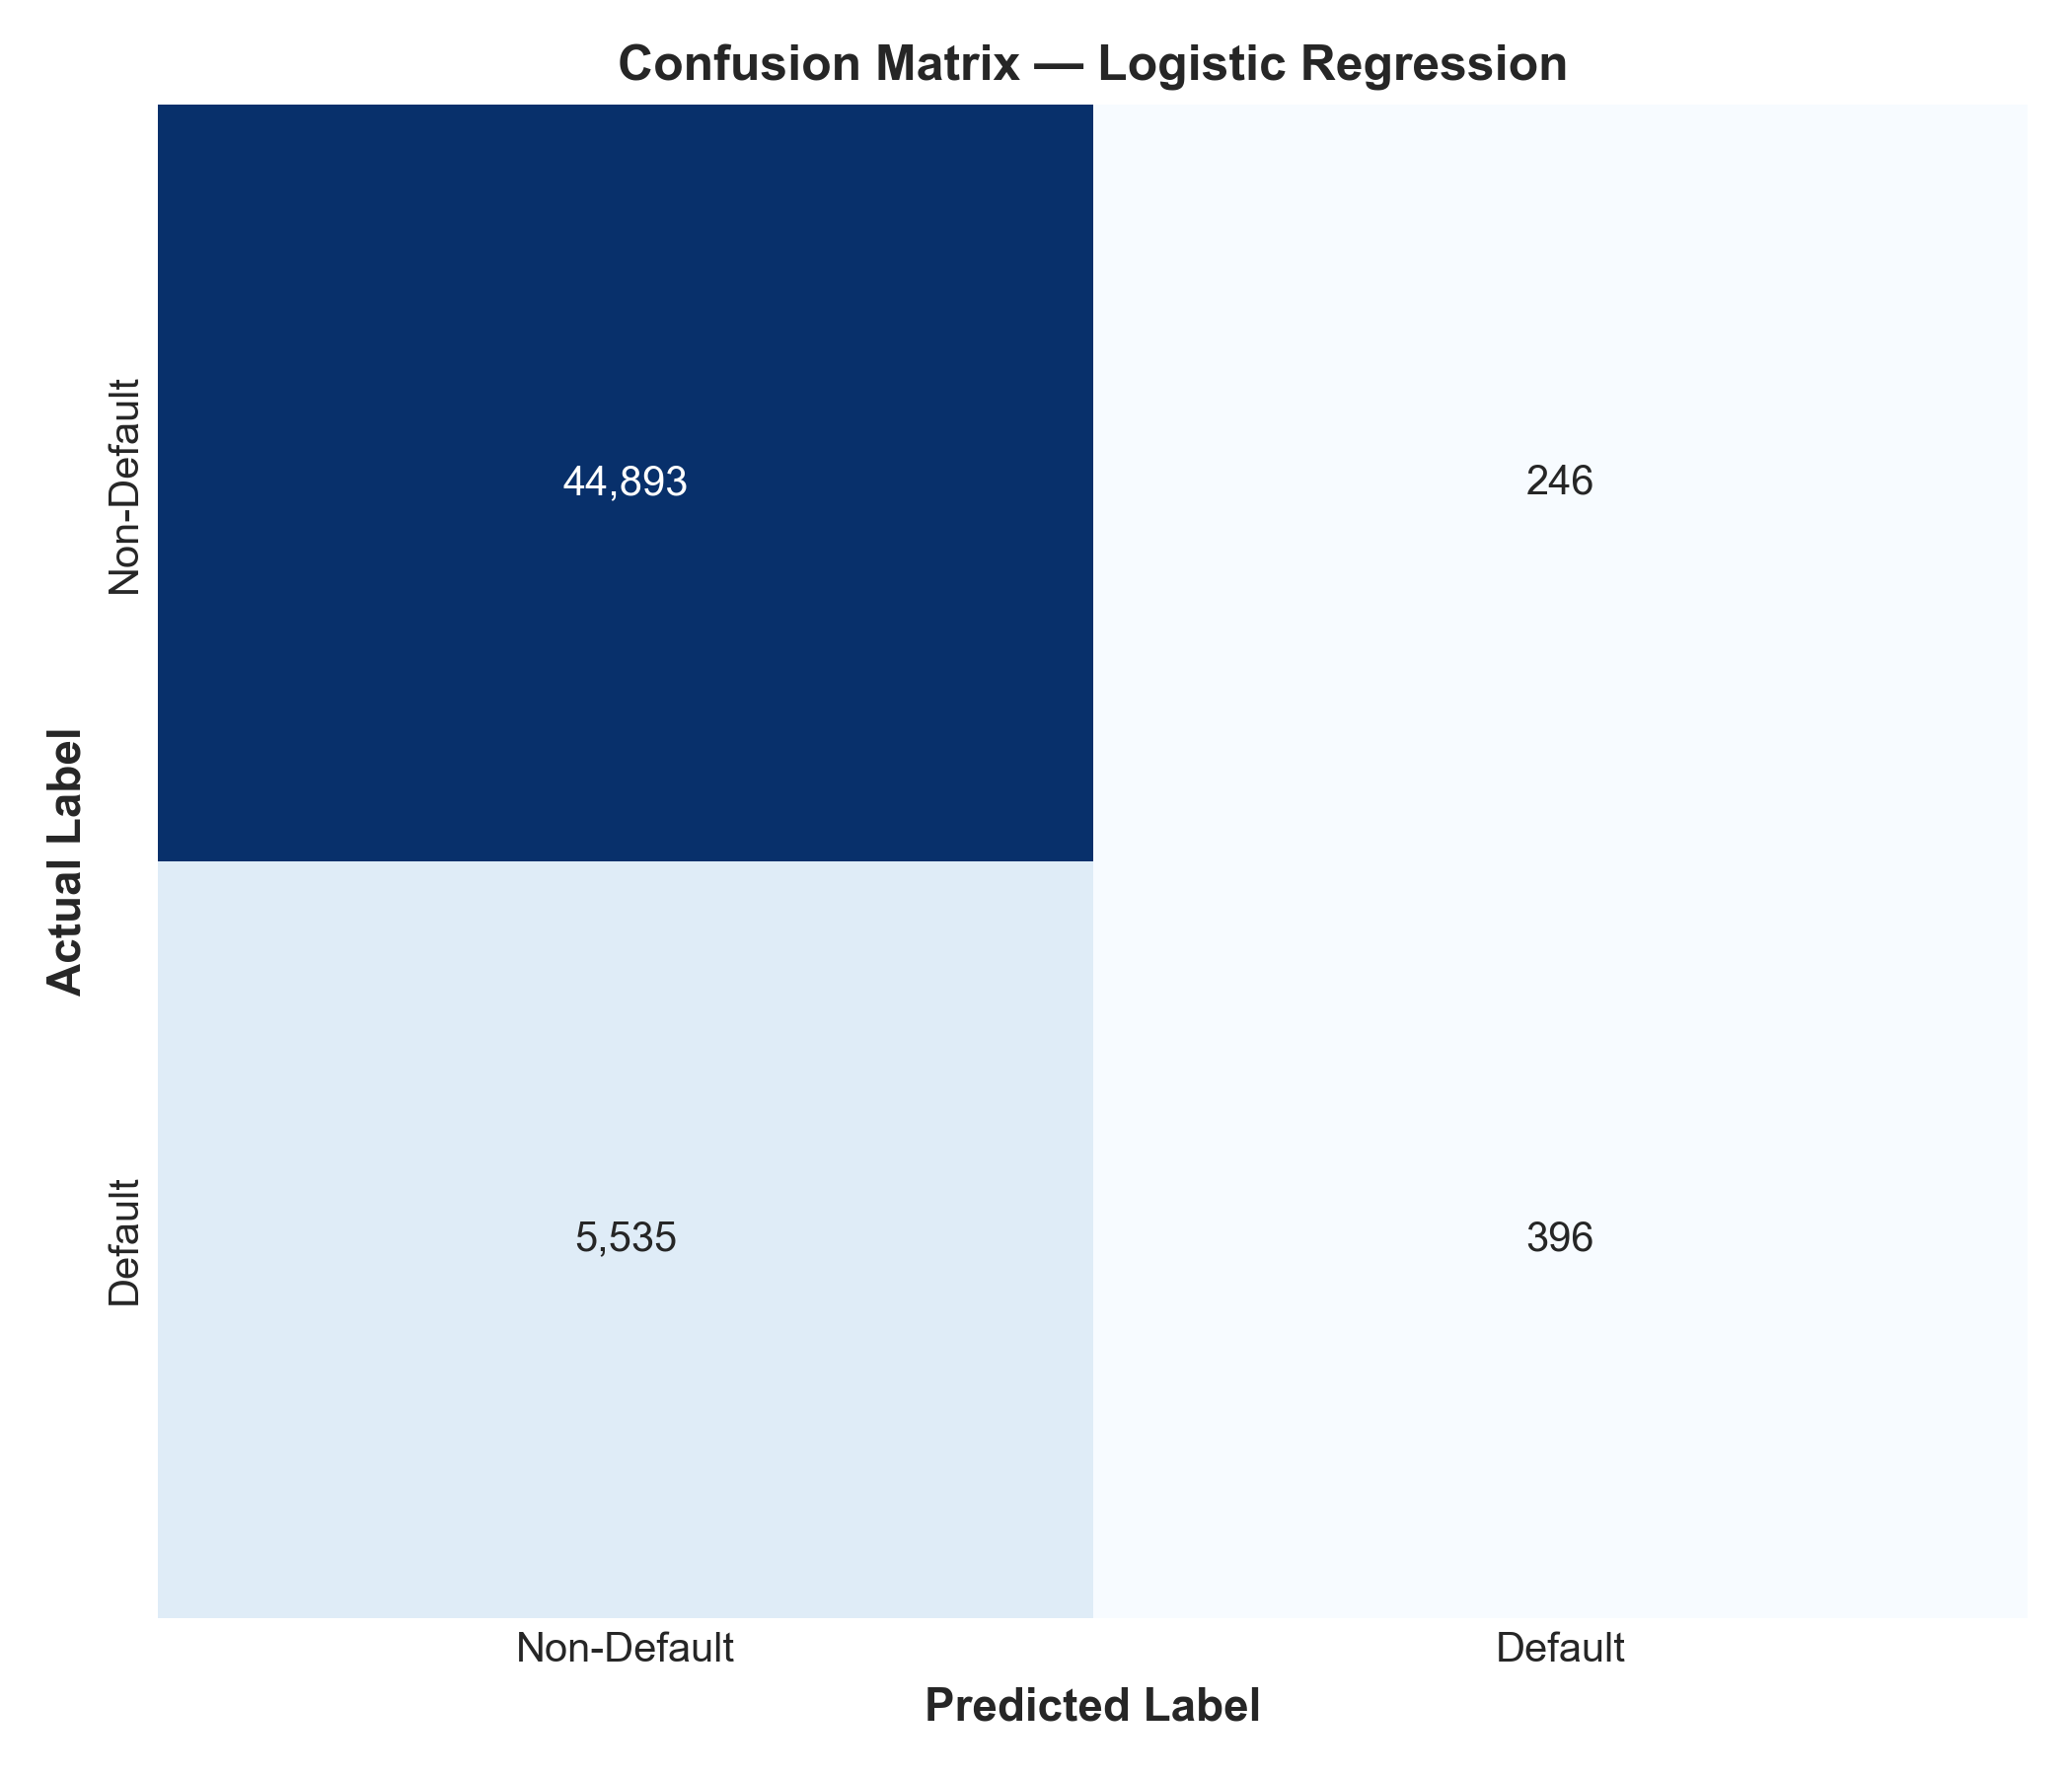

Calibration Curve:


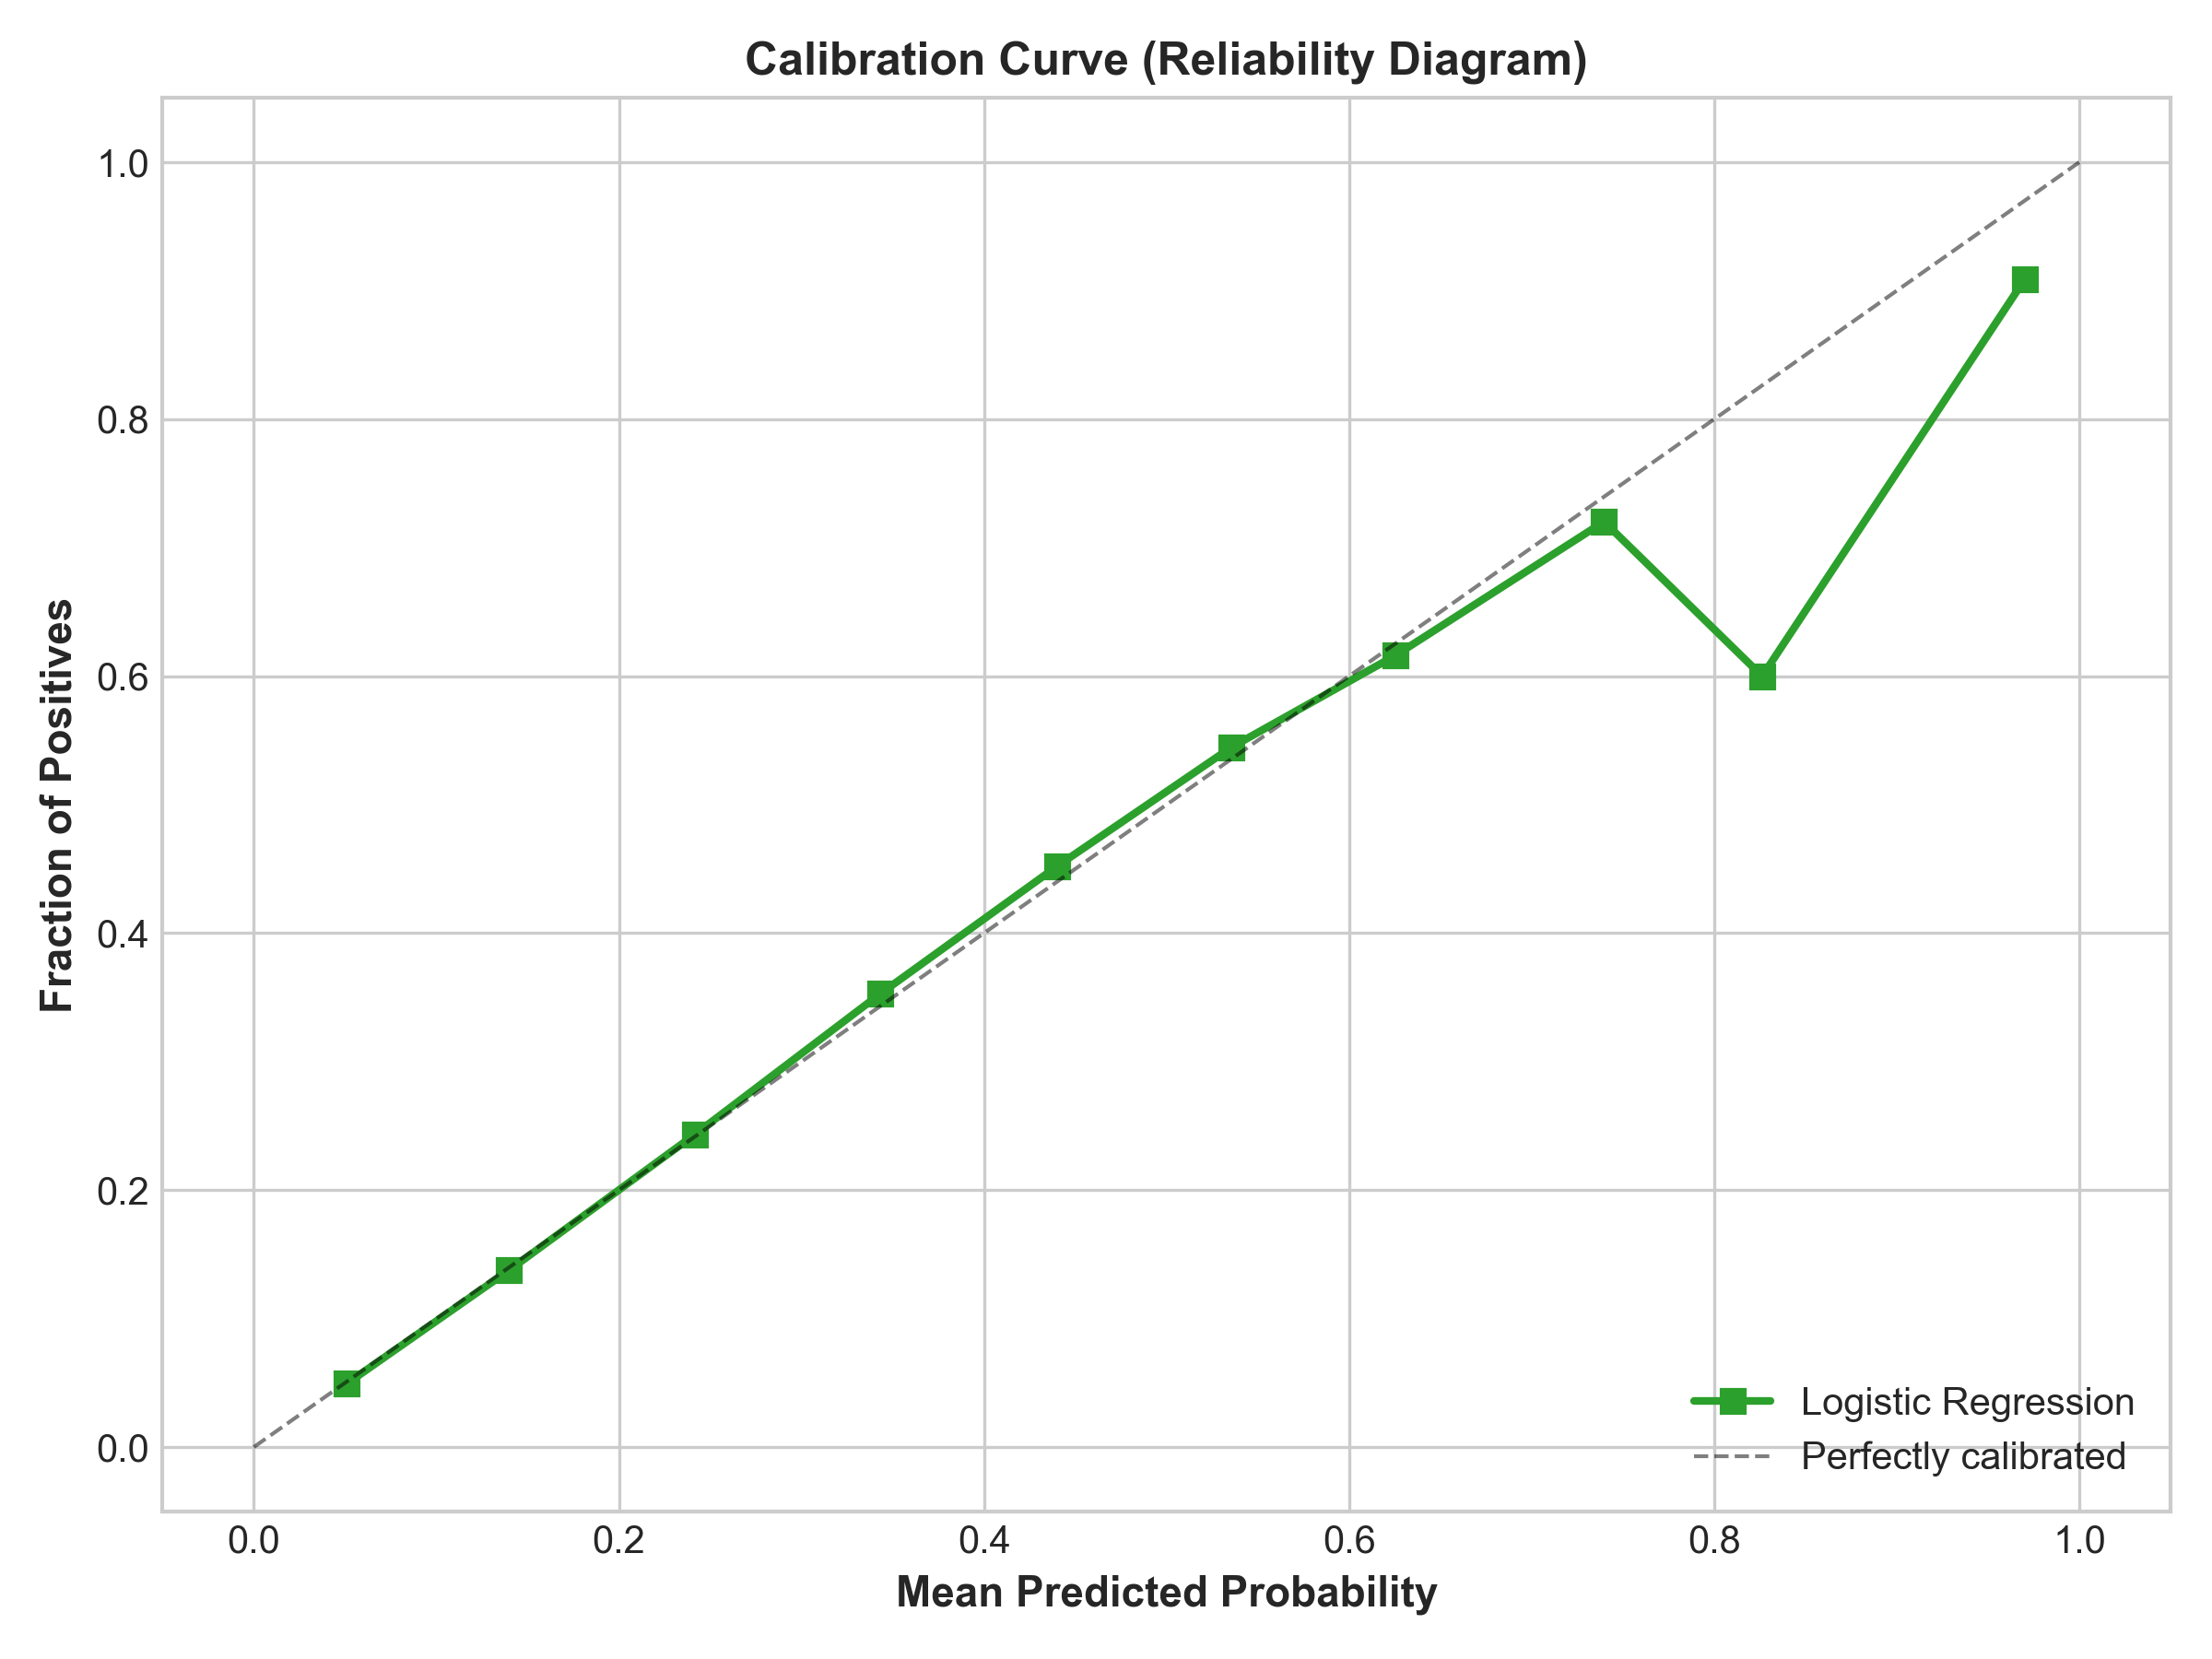

In [6]:
# Execute Step 6: Model Evaluation and Explainability
evaluate_and_explain(str(MODELS_DIR), str(REPORTS_DIR), str(IMAGES_DIR), str(DASHBOARD_DIR))

# Display Evaluation Plots
print("Confusion Matrix:")
display(Image(filename=str(IMAGES_DIR / "06_confusion_matrix.png")))
print("Calibration Curve:")
display(Image(filename=str(IMAGES_DIR / "07c_calibration_curve.png")))

### 💡 Interpretation:
- The **Confusion Matrix** shows the true performance using the business-cost optimized threshold rather than a naive 0.5 threshold.
- The **Calibration Curve (Reliability Diagram)** proves that our predicted probabilities closely match the actual fraction of defaults, meaning a prediction of 30% risk accurately reflects a 30% chance of default in the real world.

### SHAP Explainability
The summary plot below shows how individual features impacted the model's predictions.

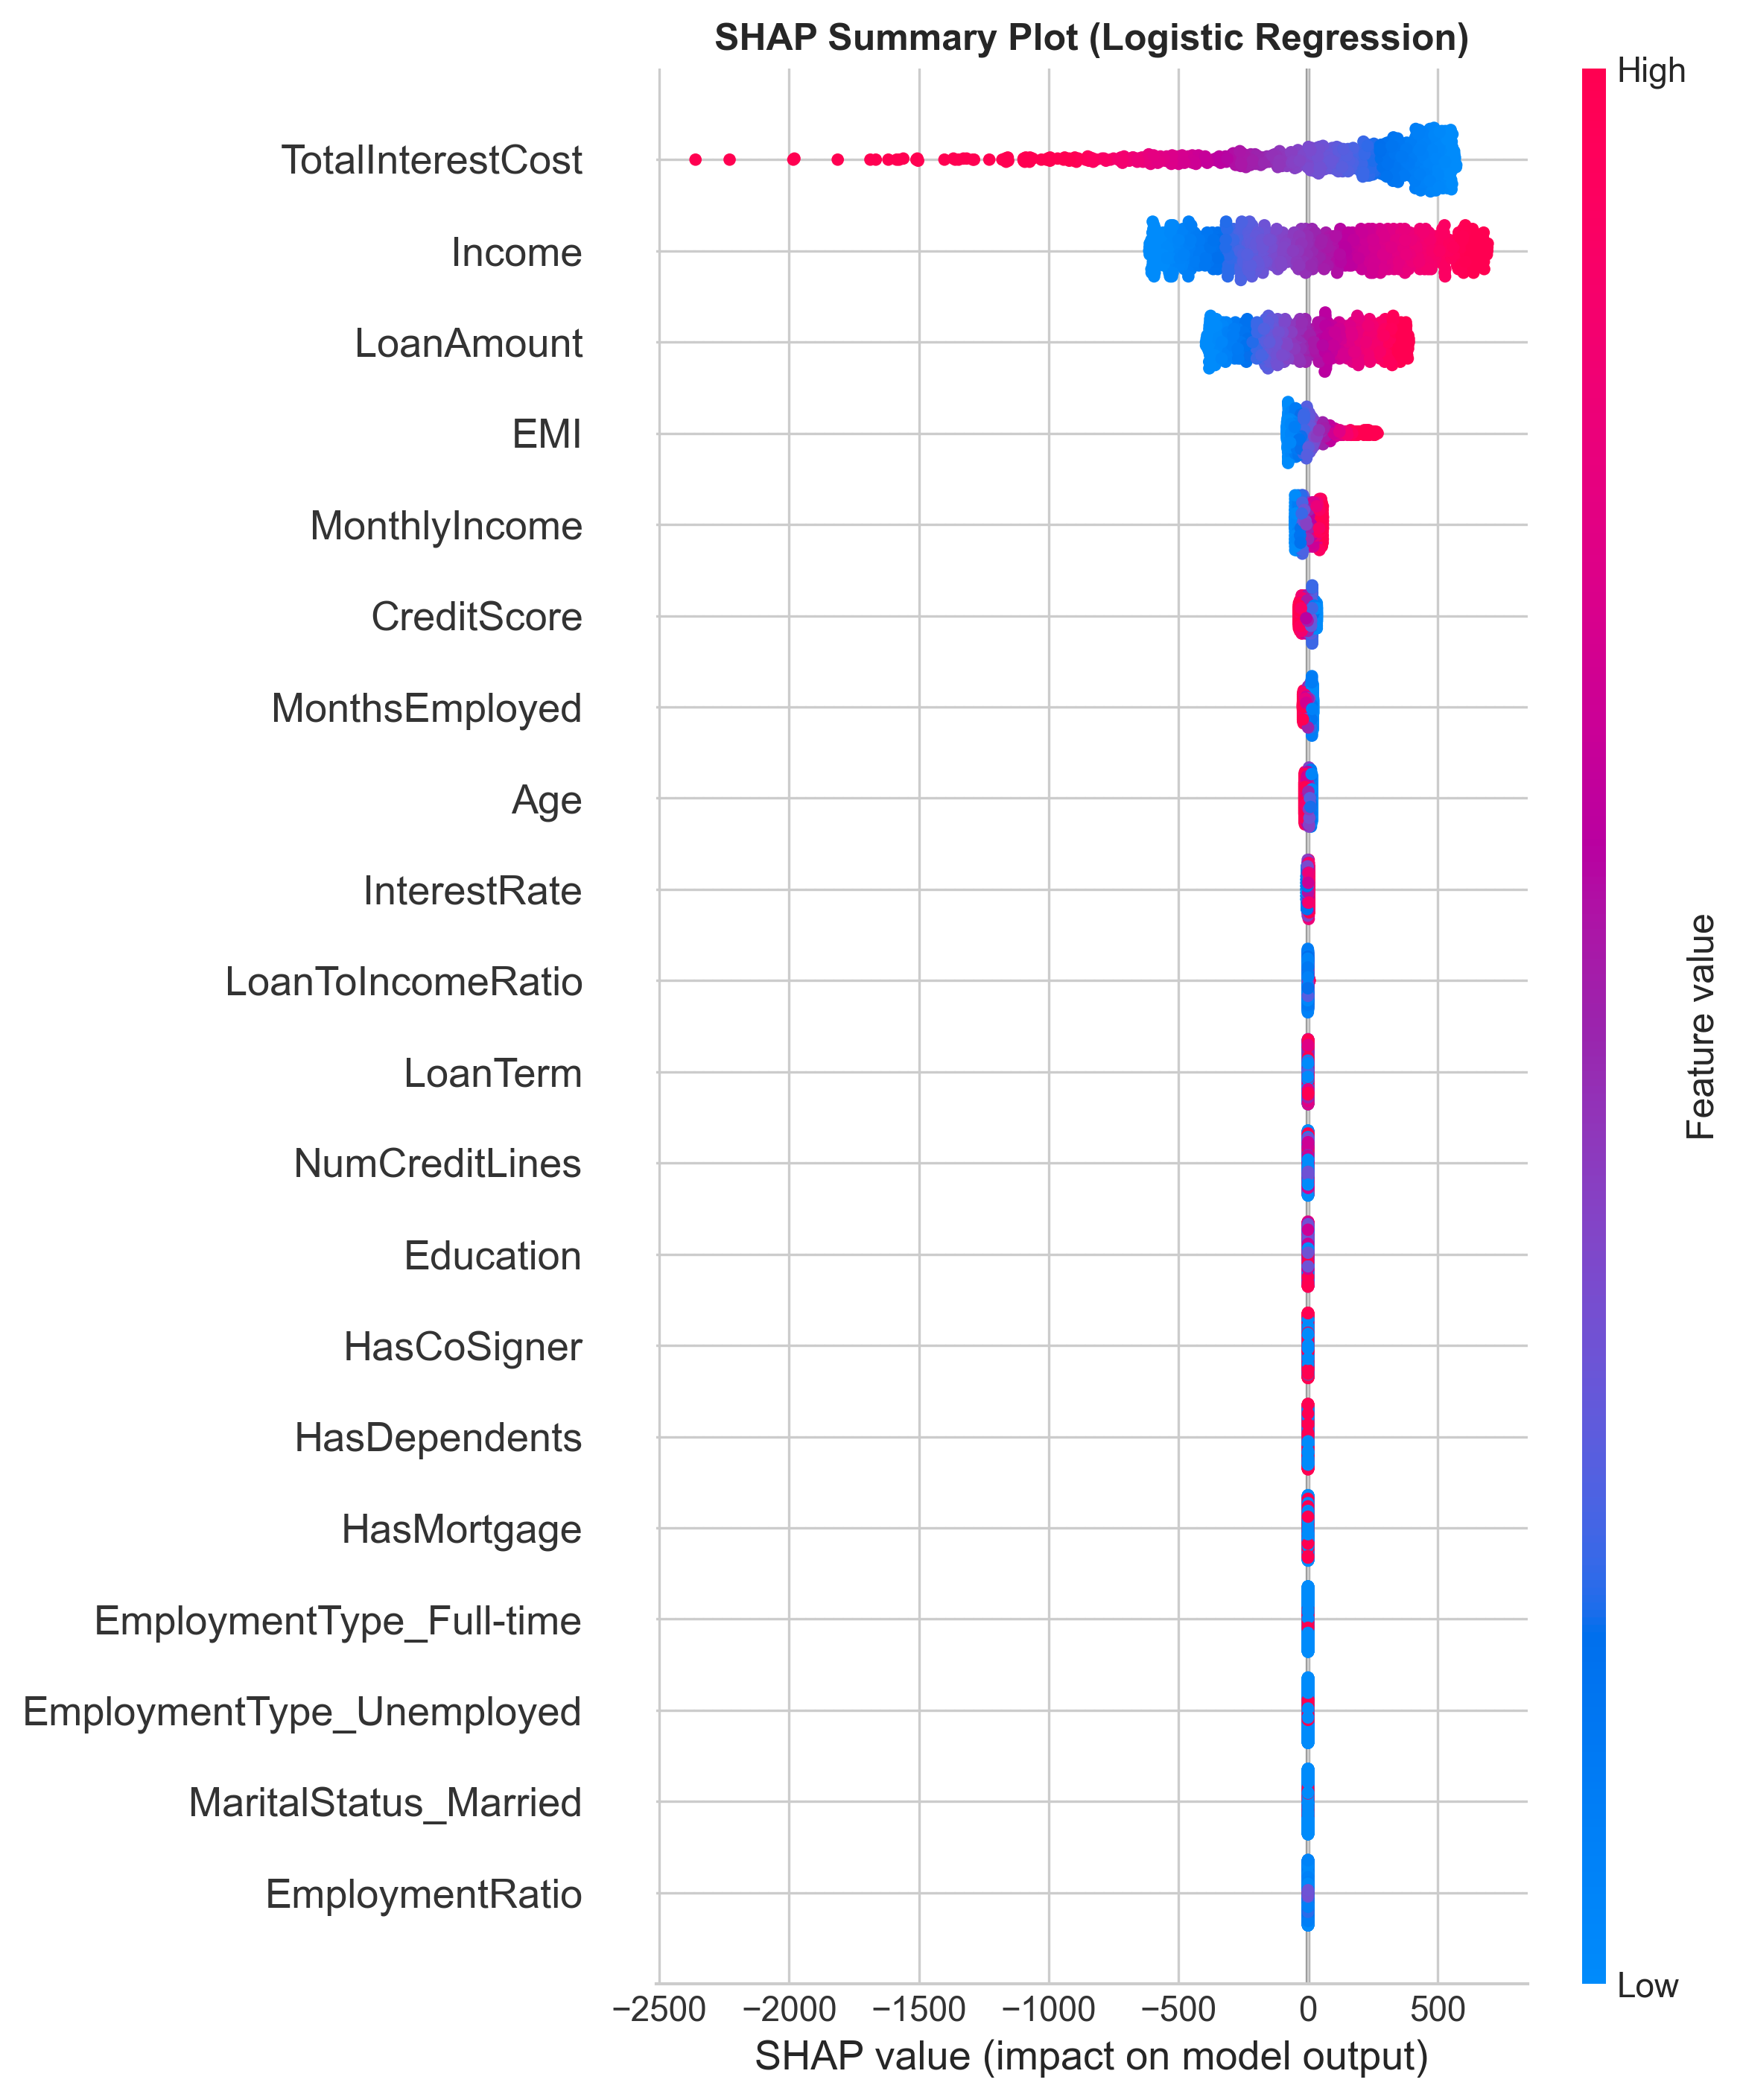

In [7]:
display(Image(filename=str(IMAGES_DIR / "09_shap_summary.png")))

### 💡 Interpretation:
The **SHAP Summary Plot** reveals the global feature importance and direction of impact. For instance, higher interest rates or lower credit scores push the model's prediction higher (towards default), aligning perfectly with real-world financial logic.

### Credit Risk Scorecard
Finally, we segment borrowers into risk tiers based on their predicted default probabilities.

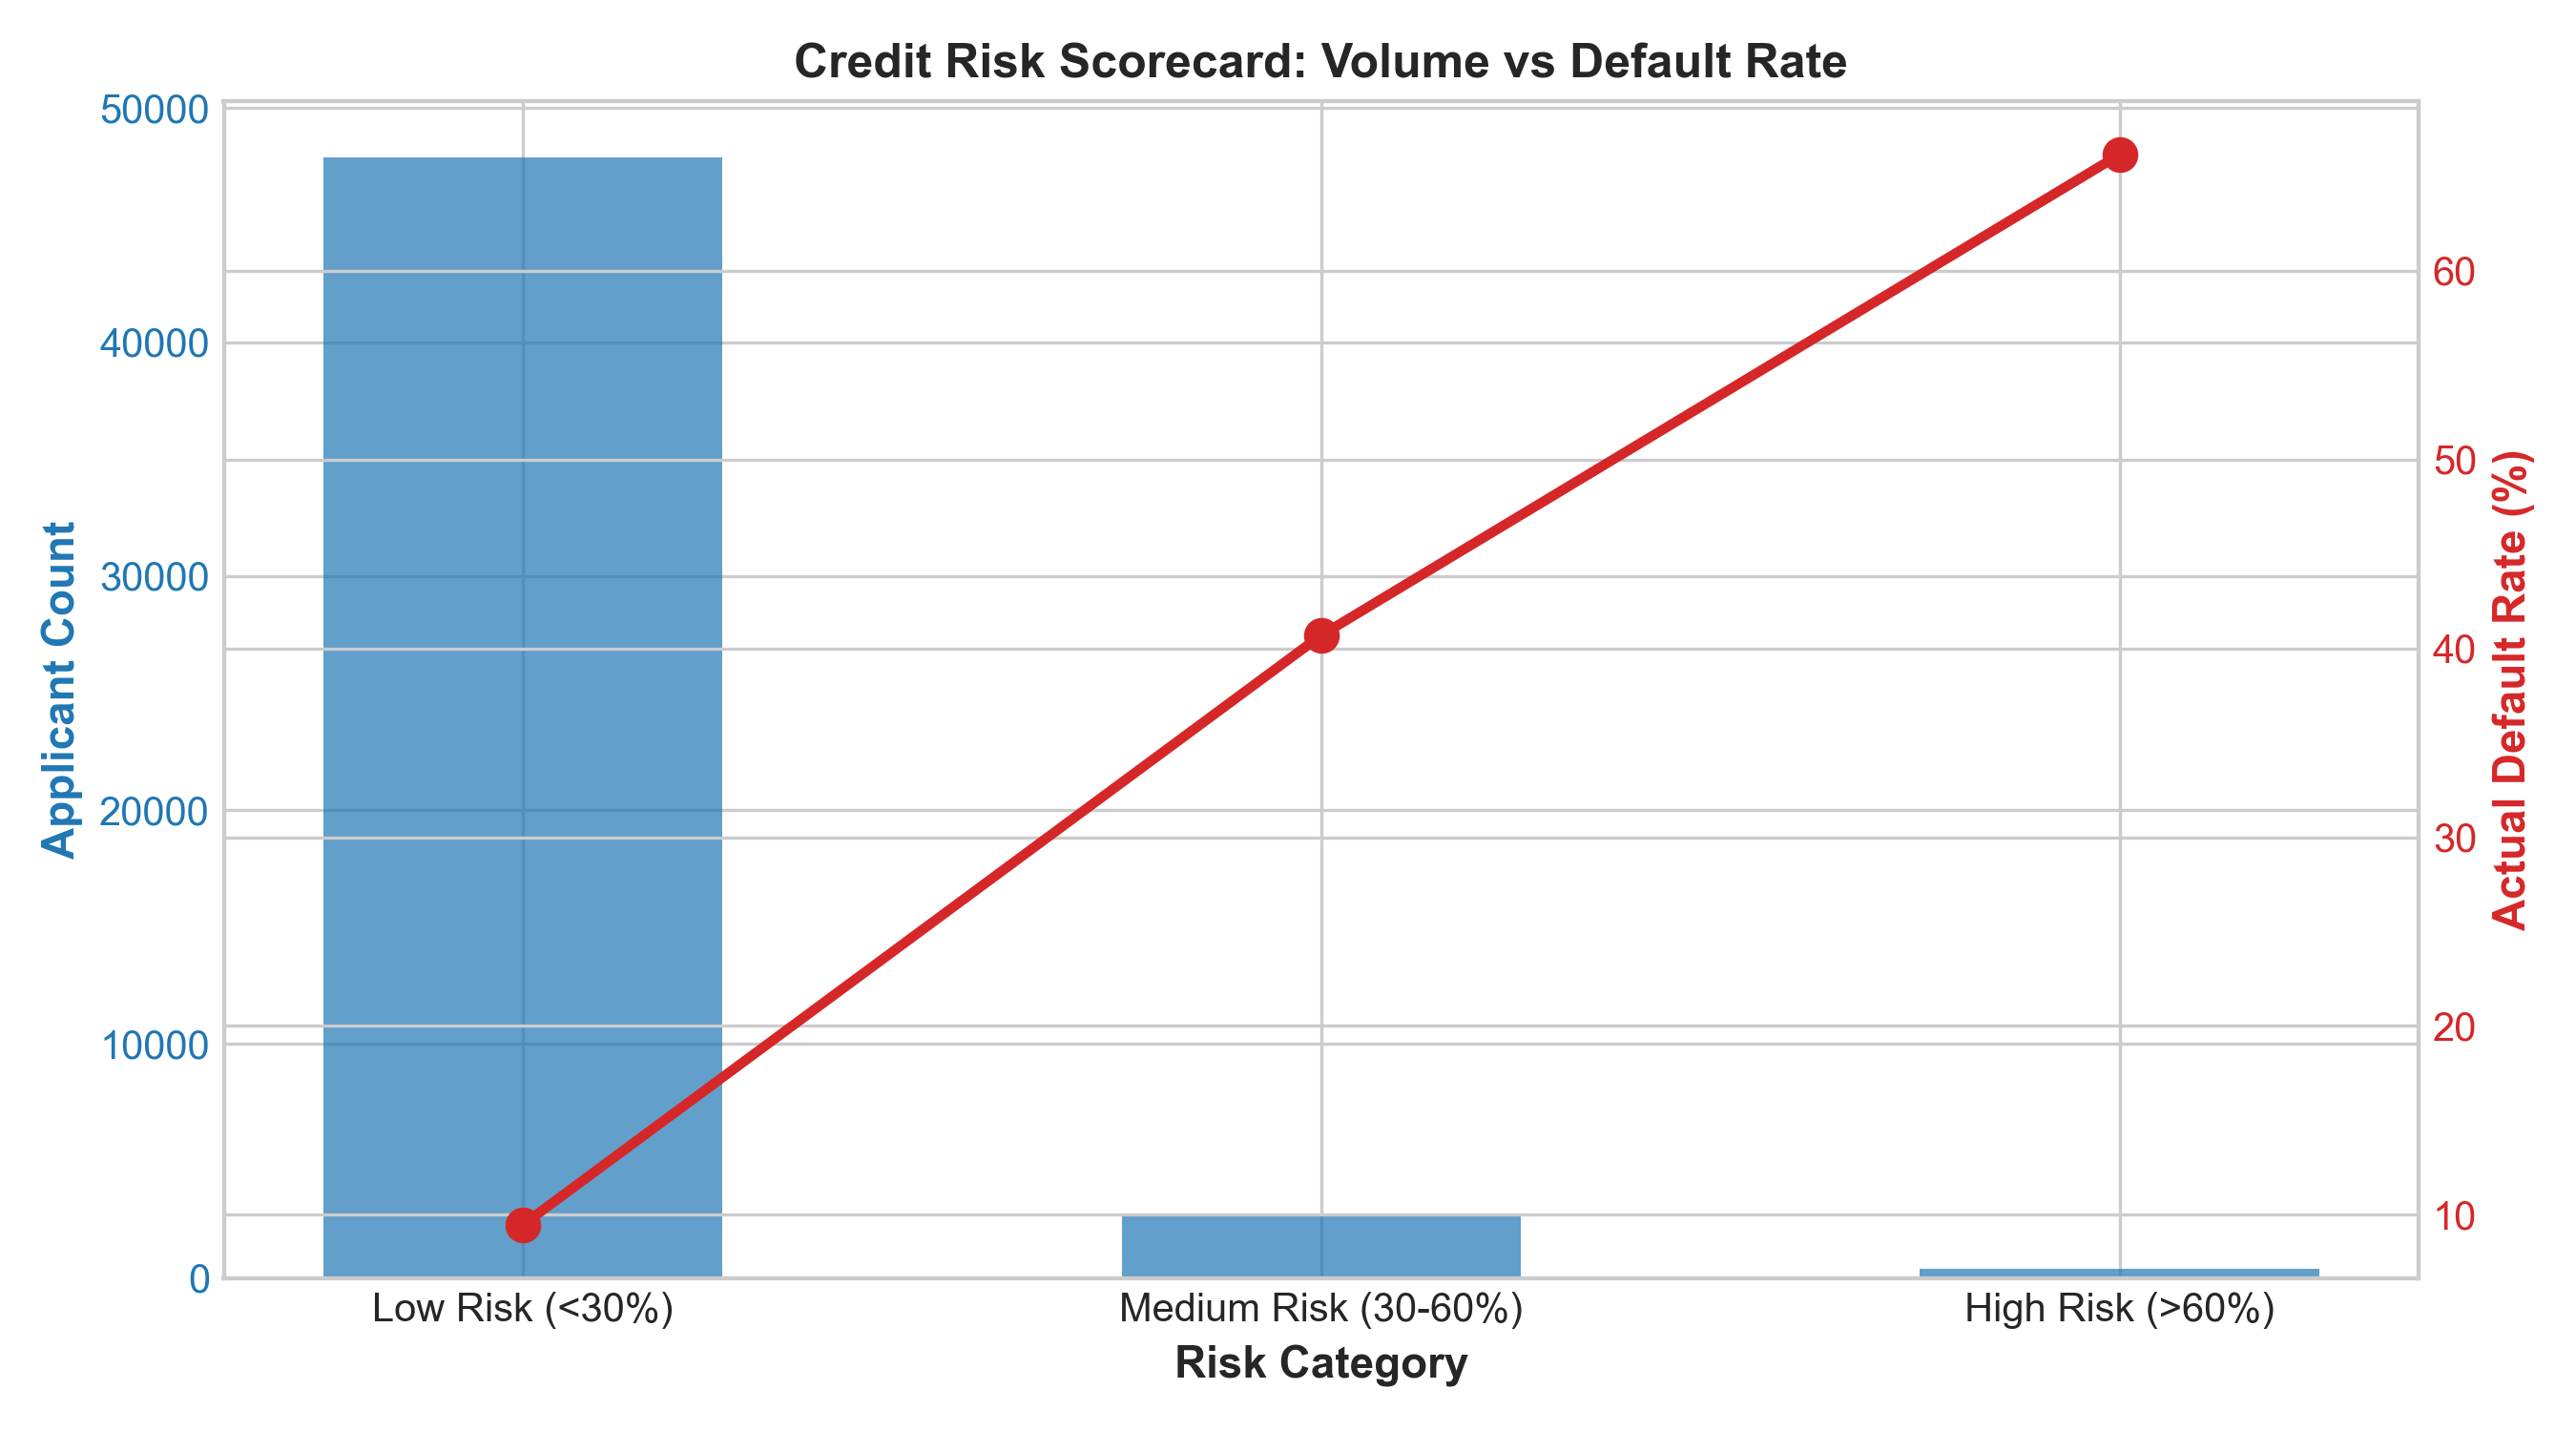

In [8]:
display(Image(filename=str(IMAGES_DIR / "10_risk_scorecard.png")))

### 💡 Interpretation:
This **Credit Risk Scorecard** bins the continuous default probabilities into Low, Medium, and High risk tiers. The overlaid line chart tracks the actual default rate in each tier. The steep upward slope validates that our model's High Risk predictions capture the vast majority of actual defaults.